In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.tree import DecisionTreeClassifier


In [ ]:
df = pd.read_csv('./Datasets/healthData.csv')

In [ ]:
df.head(2)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# EDA

In [ ]:
# ==================================================
# STROKE DATASET - COMPLETE EDA + PREPROCESSING
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")

# ==================================================
# LOAD DATA
# ==================================================

# df = pd.read_csv("stroke.csv")

# ==================================================
# 1. BASIC OVERVIEW
# ==================================================

print("="*50)
print("SHAPE")
print(df.shape)

print("\n" + "="*50)
print("INFO")
df.info()

print("\n" + "="*50)
print("NUMERICAL SUMMARY")
print(df.describe())

print("\n" + "="*50)
print("CATEGORICAL SUMMARY")
print(df.describe(include='object'))

# ==================================================
# 2. MISSING VALUES
# ==================================================

print("\n" + "="*50)
print("MISSING VALUES")
print(df.isnull().sum())

print("\n" + "="*50)
print("MISSING VALUE (%)")
print((df.isnull().sum() / len(df)) * 100)

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# ==================================================
# 3. DUPLICATE RECORDS
# ==================================================

print("\n" + "="*50)
print("DUPLICATE RECORDS")
print(df.duplicated().sum())

# ==================================================
# 4. TARGET VARIABLE ANALYSIS
# ==================================================

print("\n" + "="*50)
print("STROKE DISTRIBUTION")
print(df['stroke'].value_counts())

print("\n" + "="*50)
print("STROKE DISTRIBUTION (%)")
print(df['stroke'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.show()

# ==================================================
# 5. NUMERICAL FEATURES
# ==================================================

num_cols = df.select_dtypes(include=np.number).columns.tolist()

if 'id' in num_cols:
    num_cols.remove('id')

if 'stroke' in num_cols:
    num_cols.remove('stroke')

print("\n" + "="*50)
print("NUMERICAL COLUMNS")
print(num_cols)

# Histograms
df[num_cols].hist(figsize=(12,6), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

# Boxplots
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# ==================================================
# 6. CATEGORICAL FEATURES
# ==================================================

cat_cols = df.select_dtypes(include='object').columns.tolist()

print("\n" + "="*50)
print("CATEGORICAL COLUMNS")
print(cat_cols)

for col in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index
    )
    plt.title(f"Count Plot - {col}")
    plt.show()

# ==================================================
# 7. NUMERICAL FEATURES VS STROKE
# ==================================================

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='stroke', y=col, data=df)
    plt.title(f"{col} vs Stroke")
    plt.show()

# ==================================================
# 8. CATEGORICAL FEATURES VS STROKE
# ==================================================

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='stroke', data=df)
    plt.title(f"{col} vs Stroke")
    plt.xticks(rotation=45)
    plt.show()

# ==================================================
# 9. CORRELATION MATRIX
# ==================================================

corr_df = df.copy()

for col in corr_df.select_dtypes(include='object').columns:
    corr_df[col] = LabelEncoder().fit_transform(
        corr_df[col].astype(str)
    )

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

# ==================================================
# 10. OUTLIER DETECTION (IQR)
# ==================================================

print("\n" + "="*50)
print("OUTLIER COUNT")

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

# ==================================================
# 11. STROKE RATE BY CATEGORY
# ==================================================

for col in cat_cols:

    print("\n" + "="*50)
    print(f"STROKE RATE BY {col.upper()}")

    stroke_rate = pd.crosstab(
        df[col],
        df['stroke'],
        normalize='index'
    ) * 100

    print(stroke_rate)

# ==================================================
# 12. DATA CLEANING & ENCODING
# ==================================================

clean_df = df.copy()

# Drop ID
if 'id' in clean_df.columns:
    clean_df.drop('id', axis=1, inplace=True)

# Fill BMI missing values
if 'bmi' in clean_df.columns:
    clean_df['bmi'] = clean_df['bmi'].fillna(
        clean_df['bmi'].median()
    )

# Clean text columns
for col in clean_df.select_dtypes(include='object').columns:
    clean_df[col] = clean_df[col].astype(str).str.strip()

# ==================================================
# LABEL ENCODING (Binary Columns)
# ==================================================

binary_cols = [
    'gender',
    'ever_married',
    'Residence_type'
]

for col in binary_cols:
    if col in clean_df.columns:
        le = LabelEncoder()
        clean_df[col] = le.fit_transform(
            clean_df[col]
        )

# ==================================================
# ONE HOT ENCODING
# ==================================================

onehot_cols = [
    'work_type',
    'smoking_status'
]

existing_cols = [
    col for col in onehot_cols
    if col in clean_df.columns
]

df_encoded = pd.get_dummies(
    clean_df,
    columns=existing_cols,
    drop_first=True,
    dtype=int
)

# ==================================================
# FINAL OUTPUT
# ==================================================

print("\n" + "="*50)
print("CLEANED DATA SAMPLE")
print(clean_df.head())

print("\n" + "="*50)
print("ENCODED DATA SAMPLE")
print(df_encoded.head())

print("\n" + "="*50)
print("FINAL SHAPE")
print(df_encoded.shape)

print("\n" + "="*50)
print("MISSING VALUES AFTER CLEANING")
print(df_encoded.isnull().sum())

print("\n" + "="*50)
print("DATA TYPES")
print(df_encoded.dtypes)

print("\n" + "="*50)
print("EDA & PREPROCESSING COMPLETED SUCCESSFULLY!")

# ==================================================
# FEATURES & TARGET (READY FOR ML)
# ==================================================

X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)


In [47]:
df_encoded.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,0,1,0,0,1,0,0
1,0,61.0,0,0,1,0,202.21,28.1,1,0,0,1,0,0,1,0
2,1,80.0,0,1,1,0,105.92,32.5,1,0,1,0,0,0,1,0
3,0,49.0,0,0,1,1,171.23,34.4,1,0,1,0,0,0,0,1
4,0,79.0,1,0,1,0,174.12,24.0,1,0,0,1,0,0,1,0


In [62]:
# splitting the data into features and target variable
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
# performing Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[-0. , 0. , 0.03,...,-0. ,-0.01, 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['gender','age','hypertension',...,'smoking_status_formerly smoked', 'smoking_status_never smoked','smoking_status_smokes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.09393
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,15


In [64]:
y_pred = model.predict(X_test)
y_pred

array([-0.00286246, -0.02024573,  0.00370351, ...,  0.05321207,
        0.09469632,  0.18612898], shape=(1022,))

In [70]:
y_pred_class = (y_pred >= 0.5).astype(int)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_class))

Accuracy: 0.9393346379647749


In [ ]:
print(confusion_matrix(y_test, y_pred_class))

[[960   0]
 [ 62   0]]


# Logistic Regression

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)[:,1]

y_pred
# print(y_prob[:10])

array([0, 0, 0, ..., 0, 0, 0], shape=(1022,))

In [78]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.952054794520548


In [79]:
classification_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classification_report)


Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



# Decision Tree


In [83]:
X= df_encoded.drop('stroke', axis=1)
y= df_encoded['stroke']

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, random_state=42)

In [89]:
clf = DecisionTreeClassifier(
    criterion="entropy",   # or "entropy"
    max_depth=10,        # limit depth to avoid overfitting
    random_state=42
)
clf.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [90]:
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9315068493150684


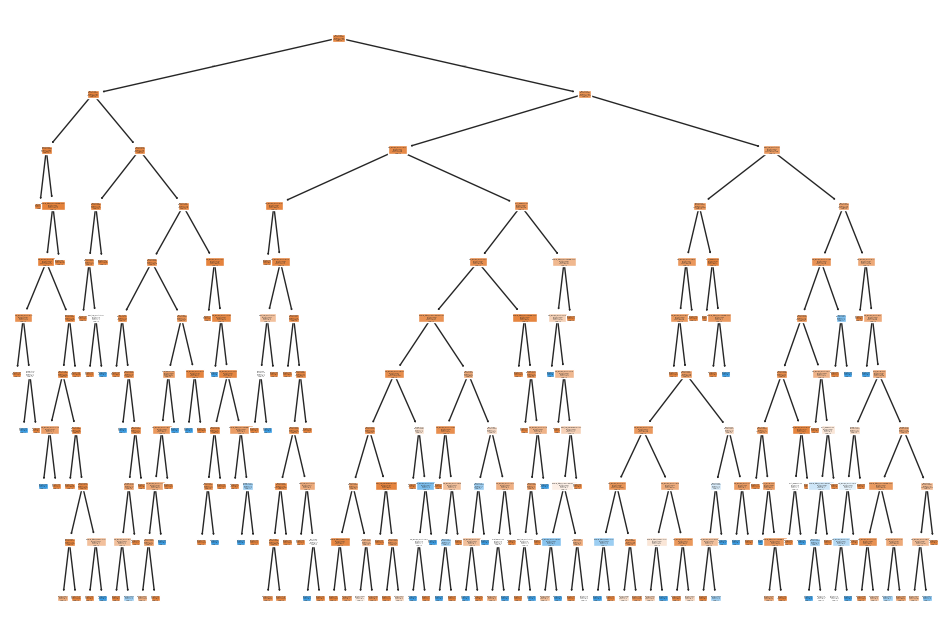

In [92]:
plt.figure(figsize=(12,8))
tree.plot_tree(clf, feature_names=X.columns, class_names=[str(c) for c in clf.classes_], filled=True)
plt.show()


In [94]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ----------------------------
# 1. Load data
# ----------------------------
# If your data is in CSV:
df = pd.read_csv("heart_data.csv")

# If you pasted data manually, assume df already exists

# ----------------------------
# 2. Encode categorical columns
# ----------------------------
le_smoker = LabelEncoder()
le_bp = LabelEncoder()
le_exercise = LabelEncoder()
le_target = LabelEncoder()

df["Smoker"] = le_smoker.fit_transform(df["Smoker"])      # yes/no → 1/0
df["BP"] = le_bp.fit_transform(df["BP"])                  # Low/Normal/High → 0/1/2
df["Exercise"] = le_exercise.fit_transform(df["Exercise"])# Yes/No → 1/0
df["HeartDisease"] = le_target.fit_transform(df["HeartDisease"])

# ----------------------------
# 3. Features & Target
# ----------------------------
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# ----------------------------
# 4. Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 5. Random Forest Model
# ----------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ----------------------------
# 6. Predictions
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# 7. Evaluation
# ----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        22
           1       1.00      0.94      0.97        18

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



In [95]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))


Smoker         0.380315
Age            0.231172
Cholesterol    0.210291
BP             0.110126
Exercise       0.068097
dtype: float64


In [ ]:
importances = model.feature_importances_
plt.figure(figsize=(12,8))
plt.bar(range(len(importances)), importances, tick_label=df.columns)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest")
plt.show()